# Projekt: Wie beeinflusst die Lieferzeit die Kundenzufriedenheit?

**Das Problem:**
Im Online-Handel ist es sehr teuer, neue Kunden zu gewinnen. Deshalb ist es extrem wichtig, dass bestehende Kunden zufrieden sind und wieder einkaufen. Wenn Kunden wegen langen Lieferzeiten unzufrieden sind und nicht mehr bestellen, verliert das Unternehmen viel Geld.

**Unsere Forschungsfrage:**
Welchen messbaren Einfluss hat die Lieferzeit auf die vergebenen Sterne-Bewertungen? Wir wollen den exakten Trend Tag für Tag sichtbar machen. Das Ziel ist es, dem Management mit echten Daten zu beweisen, wie schnell Pakete ankommen müssen, um die Zufriedenheit auf einem profitablen Niveau zu halten.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


### Schritt 1: Daten-Import und Qualitätskontrolle
Die Rohdaten werden geladen. Im Anschluss suchen wir nach Fehlern oder fehlenden Werten in der Tabelle und machen die Daten sauber. Das ist das Fundament für unsere Analyse.

In [2]:
# Kundendaten laden und die ersten 5 Zeilen prüfen
kunden = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
kunden.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
#  Fehlende Werte prüfen
kunden.isnull().sum()


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [4]:
# Bestellungendaten  laden und die ersten 5 Zeilen prüfen
bestellungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
bestellungen.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
#  Fehlende Werte prüfen
bestellungen.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
# Fehlende Werte löschen und nochmal prüfen
bestellungen.dropna(subset=['order_delivered_customer_date'], inplace=True)
bestellungen.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64

In [7]:
#  Das Kaufdatum von Text in ein echtes Datum weckseln
bestellungen['order_purchase_timestamp'] = pd.to_datetime(bestellungen['order_purchase_timestamp'])

#  Das Lieferdatum von Text in ein echtes Datum weckseln
bestellungen['order_delivered_customer_date'] = pd.to_datetime(bestellungen['order_delivered_customer_date'])

# Kontrollieren
bestellungen.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96476 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96476 non-null  object        
 1   customer_id                    96476 non-null  object        
 2   order_status                   96476 non-null  object        
 3   order_purchase_timestamp       96476 non-null  datetime64[ns]
 4   order_approved_at              96462 non-null  object        
 5   order_delivered_carrier_date   96475 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96476 non-null  object        
dtypes: datetime64[ns](2), object(6)
memory usage: 6.6+ MB


### Schritt 2: Die Master-Tabelle erstellen
Die sauberen Einzel-Tabellen werden jetzt zu einer großen Haupt-Tabelle verschmolzen. Als Verbindungsstück zwischen den Tabellen nutzen wir die Spalte `customer_id`. Ab jetzt arbeiten wir nur noch mit dieser zusammengefassten Master-Tabelle.

In [8]:
# Verschmelzen Bestellungen und Kunden zu einer neuen Master-Tabelle
master_tabelle = pd.merge(bestellungen, kunden, on='customer_id', how='inner')
master_tabelle.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


### Schritt 3: Berechnung der Lieferdauer in Tagen
Wir erschaffen eine neue Daten-Spalte. Dafür rechnet das System: "Lieferdatum minus Kaufdatum". Das Ergebnis zeigt uns die exakten Liefertage an.

In [9]:
# berechnen  Lieferzeit in Tagen 
master_tabelle['lieferzeit_tage'] = (master_tabelle['order_delivered_customer_date'] - master_tabelle['order_purchase_timestamp']).dt.days

# prüfen mithilfe den relevanten Spalten
master_tabelle[['order_purchase_timestamp', 'order_delivered_customer_date', 'lieferzeit_tage']].head(10)

,order_purchase_timestamp,order_delivered_customer_date,lieferzeit_tage
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2
5,2017-07-09 21:57:05,2017-07-26 10:57:55,16
6,2017-05-16 13:10:30,2017-05-26 12:55:51,9
7,2017-01-23 18:29:09,2017-02-02 14:08:10,9
8,2017-07-29 11:55:02,2017-08-16 17:14:30,18
9,2017-05-16 19:41:10,2017-05-29 11:18:31,12


### Schritt 4: Kundenbewertungen laden und isolieren
Die Lieferzeit allein reicht nicht aus. Wir müssen wissen, wie zufrieden die Kunden waren. Dafür laden wir die Tabelle mit den Bewertungen (1 bis 5 Sterne). Wir filtern sofort die zwei wichtigsten Spalten heraus (Bestellnummer und Sterne) und prüfen diese auf leere Felder, um sauber weiterarbeiten zu können.

In [10]:
# Bewertungsdaten laden 
bewertungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')
# Isolieren mit Variablen order_ID und review_score 
bewertungen_isoliert = bewertungen[['order_id', 'review_score']]
# prüfen
bewertungen_isoliert.head()
# prüfen Sauberkeit
bewertungen_isoliert.isnull().sum()

order_id        0
review_score    0
dtype: int64

### Schritt 5: Tabellen zusammenfügen
Wir verbinden die Bewertungen über die Bestellnummer (`order_id`) mit unserer Master-Tabelle. So haben wir Lieferdauer und Sterne-Bewertung endlich zusammen an einem Ort.

In [11]:
# Verschmelzen (Merge)  master_tabelle und bewertungen_isoliert
finale_tabelle = pd.merge(master_tabelle, bewertungen_isoliert, on='order_id', how='inner')
# prüfen
finale_tabelle.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,lieferzeit_tage,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,8,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,13,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,9,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,13,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2,5


### Schritt 6: Den Durchschnitt berechnen (Daten zusammenfassen)
Um ein klares Muster zu erkennen, fassen wir die Daten zusammen. Wir berechnen für jeden einzelnen Liefer-Tag den Durchschnitt der Sterne-Bewertungen. Das ist das finale Fundament für unser Diagramm.

In [12]:
# Durchschnittliche Sterne pro Liefer-Tag berechnen
bewertung_pro_tag = finale_tabelle.groupby('lieferzeit_tage')['review_score'].mean().reset_index()
# runden die Ergebnisse mit 2
bewertung_pro_tag['review_score'] = bewertung_pro_tag['review_score'].round(2)
# prüfen
bewertung_pro_tag.head(10)

,lieferzeit_tage,review_score
0,0,4.23
1,1,4.50
2,2,4.48
3,3,4.43
4,4,4.43
5,5,4.39
6,6,4.38
7,7,4.38
8,8,4.35
9,9,4.30


### Schritt 7: Daten visualisieren (Liniendiagramm)
Tabellen sind schwer zu lesen. Wir wandeln unsere Daten jetzt in ein klares Liniendiagramm um (Fokus auf die ersten 30 Tage). So sehen wir den Trend der Zufriedenheit auf einen Blick.

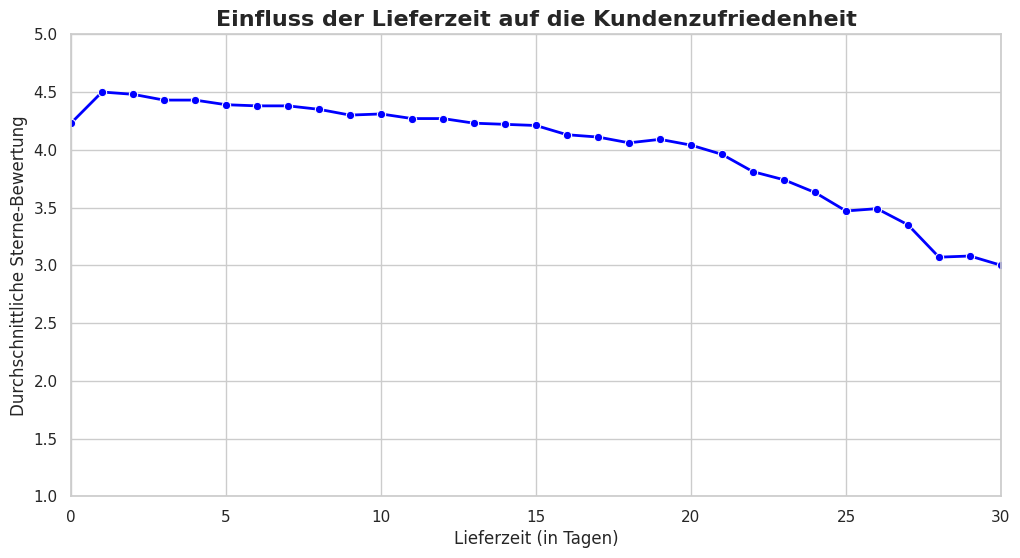

In [13]:
# Wichtige Bibliotheken für Grafiken laden
import matplotlib.pyplot as plt
import seaborn as sns

# Ein sauberes Design auswählen
sns.set_theme(style="whitegrid")

# Die Größe des Diagramms festlegen
plt.figure(figsize=(12, 6))

# Das reine Liniendiagramm zeichnen
sns.lineplot(data=bewertung_pro_tag, x='lieferzeit_tage', y='review_score', marker='o', color='blue', linewidth=2)

# Titel und Achsen beschriften
plt.title('Einfluss der Lieferzeit auf die Kundenzufriedenheit', fontsize=16, fontweight='bold')
plt.xlabel('Lieferzeit (in Tagen)', fontsize=12)
plt.ylabel('Durchschnittliche Sterne-Bewertung', fontsize=12)

# Achsen-Grenzen festlegen (Nur bis Tag 30, Sterne von 1 bis 5)
plt.xlim(0, 30)
plt.ylim(1, 5)

# Diagramm anzeigen
plt.show()

### Fazit zu Frage 1: Was uns das Diagramm zeigt

**1. Die generelle Übersicht und der Ergebnis**
Das Diagramm zeigt ein sehr klares Bild: Je länger ein Kunde auf sein Paket wartet, desto schlechter wird die Bewertung. 
* Bei einer sehr schnellen Lieferung (1 bis 4 Tage) sind die Kunden am glücklichsten und geben im Durchschnitt fast 4,5 Sterne. 
* Danach geht die Linie eindeutig und konstant nach unten. Bei 30 Tagen Wartezeit sind wir bereits bei nur noch 3 Sternen angekommen.

**2. Warum ist die Linie nicht perfekt glatt?**
 Die Kunden bewerten nicht *nur* die Lieferzeit. Ein Paket kann super schnell ankommen, aber wenn das Produkt kaputt ist oder der Paketbote unfreundlich war, gibt es trotzdem nur 1 Stern. Das sorgt für die kleinen Schwankungen in unserer Linie.
 
* **Das Rätsel um "Tag 0":** Warum ist eine Lieferzeit von 0 Tagen (4.23 Sterne) schlechter als 1 Tag (4.50 Sterne)? In der Realität bedeutet "0 Tage" oft, dass es Probleme gab. Zum Beispiel hat der Kunde die Bestellung sofort wieder storniert oder das System hatte einen Fehler. Das macht Kunden wütend und drückt den Durchschnitt nach unten.
